# Validating Eq. 8, Eq. 14 and Eq. 18 independently

NOT EXECUTED on my side, at your request. Syntax-checked only.

| eq | what it says | tested how |
|----|--------------|------------|
| **8**  | `p_c = min(theta, 2*arcsin(r/VR)) / (2*pi)` | **direct microscopic MC** — one isolated target, one step. Does NOT use the MFPT, `A`, `b`, or any fitted constant. This is the cleanest of the three. |
| **14** | `T_vis = (VR^2-tau^2) + A*ln(tau/VR_eff) + eps*VR` | three separate sub-tests, because a single pass/fail would conflate the *structure* with the *fitted constants* |
| **18** | `T_blind = T_inf*(1 - B*(r/tau)^psi)` | tau-scan + fit; checks `T_inf` against the analytic MFP and discriminates `psi=1` vs `psi=2` |

**Read the caveat in section 5 before trusting any of it.** The dominant error
here is almost certainly NOT the walker count.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit

# ============ YOUR PARAMETERS ============
L, Nt, r = 300, 90, 0.5
TAU = 8.0
THETA = 2 * np.pi
# =========================================

D_STEP = 1.0                      # physical step -> D = d/4 = 1/4
rho = Nt / L**2
A = 2 / (np.pi * rho)
B_CELL = 1 / np.sqrt(np.pi * rho)
MFP = 1 / (2 * r * rho)

# fitted constants under test
ELL_A, ELL_C = 1.79, 0.45
CONE_A, CONE_C = 1.97, 0.56
EPS = 0.8                         # run-in cost ~ EPS*VR
KAPPA = 0.52                      # contact floor = KAPPA*r  (when d > r)
B_OPT, B_PURE, PSI = 0.73, 0.38, 1.0

print(f"rho={rho:.4g}  A={A:.1f}  b={B_CELL:.2f}  MFP={MFP:.1f}  tau={TAU}")
print(f"windows: model needs 3d={3*D_STEP} <= VR < tau <= 0.6b={0.6*B_CELL:.1f}; "
      f"sim needs tau < L/3={L/3:.1f}")

rho=0.001  A=636.6  b=17.84  MFP=1000.0  tau=8.0
windows: model needs 3d=3.0 <= VR < tau <= 0.6b=10.7; sim needs tau < L/3=100.0


## Simulators (self-contained)

In [ ]:
def _minimg(delta, L):
    return delta - L * np.round(delta / L)


def run_visual(L, Nt, r, VR, tau, theta, W, seed, rule='dir', max_steps=200000):
    """Diffusive visual searcher. Vision (cone+dash) OR contact. Returns (path, done)."""
    rng = np.random.default_rng(seed)
    targets = rng.uniform(0, L, size=(Nt, 2))
    tree = cKDTree(targets, boxsize=L)
    ti = rng.integers(0, Nt, size=W)
    a0 = rng.uniform(0, 2 * np.pi, size=W)
    pos = (targets[ti] + tau * np.column_stack([np.cos(a0), np.sin(a0)])) % L
    path = np.zeros(W); done = np.zeros(W, bool); idx = np.arange(W)
    half = theta / 2.0
    Rsearch = max(VR, D_STEP + r) + 1e-9
    for _ in range(max_steps):
        act = ~done
        if not act.any():
            break
        p = pos[act]; ai = idx[act]
        if rule == 'iso':
            dist, _ = tree.query(p, k=1)
            hit = dist <= VR
            if hit.any():
                path[ai[hit]] += dist[hit]; done[ai[hit]] = True
            mv = ~hit
            if mv.any():
                ang = rng.uniform(0, 2 * np.pi, size=int(mv.sum()))
                pos[ai[mv]] = (p[mv] + np.column_stack([np.cos(ang), np.sin(ang)])) % L
                path[ai[mv]] += D_STEP
            continue
        ang = rng.uniform(0, 2 * np.pi, size=len(p))
        h = np.column_stack([np.cos(ang), np.sin(ang)])
        capt = np.zeros(len(p), bool); cost = np.zeros(len(p))
        neigh = tree.query_ball_point(p, Rsearch)
        for k in range(len(p)):
            lst = neigh[k]
            if not lst:
                continue
            dvec = _minimg(targets[lst] - p[k], L)
            dd = np.hypot(dvec[:, 0], dvec[:, 1])
            s = dvec[:, 0] * h[k, 0] + dvec[:, 1] * h[k, 1]
            cross = h[k, 0] * dvec[:, 1] - h[k, 1] * dvec[:, 0]
            perp = np.abs(cross)
            ray_hits = (perp <= r) & (s > 0)
            if not ray_hits.any():
                continue
            entry = np.where(ray_hits, s - np.sqrt(np.clip(r**2 - perp**2, 0, None)), np.inf)
            entry = np.clip(entry, 0.0, None)
            bear = np.abs(np.arctan2(cross, s))
            vision = ray_hits & (dd <= VR) & (bear <= half)
            contact = ray_hits & (entry <= D_STEP)
            ok = vision | contact
            if ok.any():
                capt[k] = True; cost[k] = entry[ok].min()
        if capt.any():
            path[ai[capt]] += cost[capt]; done[ai[capt]] = True
        mv = ~capt
        if mv.any():
            pos[ai[mv]] = (p[mv] + h[mv]) % L; path[ai[mv]] += D_STEP
    return path, done


def mfpt_visual(**kw):
    path, done = run_visual(**kw)
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1 - done.mean()


def run_flight(L, Nt, r, tau, dscales, weights, W, seed, h=0.2, max_path=40000):
    """Blind ballistic biexponential searcher. h is NUMERICAL (0.2 converged)."""
    rng = np.random.default_rng(seed)
    targets = rng.uniform(0, L, size=(Nt, 2))
    tree = cKDTree(targets, boxsize=L)
    ti = rng.integers(0, Nt, size=W)
    a0 = rng.uniform(0, 2 * np.pi, size=W)
    pos = (targets[ti] + tau * np.column_stack([np.cos(a0), np.sin(a0)])) % L
    head = np.zeros((W, 2)); remaining = np.zeros(W)
    path = np.zeros(W); done = np.zeros(W, bool)
    dscales = np.asarray(dscales, float)
    cw = np.cumsum(np.asarray(weights, float)); cw /= cw[-1]

    def new_flights(mask):
        n = int(mask.sum())
        if n == 0:
            return
        mode = np.searchsorted(cw, rng.random(n))
        Ls = -dscales[mode] * np.log(rng.random(n))
        ang = rng.uniform(0, 2 * np.pi, n)
        head[mask] = np.column_stack([np.cos(ang), np.sin(ang)])
        remaining[mask] = Ls

    new_flights(~done)
    for _ in range(int(max_path / h)):
        act = ~done
        if not act.any():
            break
        new_flights(act & (remaining <= 0))
        pos[act] = (pos[act] + h * head[act]) % L
        remaining[act] -= h; path[act] += h
        d_near, _ = tree.query(pos[act], k=1)
        hit = d_near <= r
        if hit.any():
            done[np.where(act)[0][hit]] = True
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1 - done.mean()

## Theory under test

In [ ]:
def p_c_eq8(theta, r, VR):
    return min(theta, 2 * np.arcsin(min(r / VR, 1.0))) / (2 * np.pi)


def ell_eq11_12(VR, r, theta=2 * np.pi):
    e = ELL_A * np.log(VR / r) + ELL_C
    pcw, pcn = p_c_eq8(2 * np.pi, r, VR), p_c_eq8(theta, r, VR)
    if pcn < pcw:
        e += CONE_A * np.log(pcw / pcn) + CONE_C
    return max(e, 0.0)


def VR_eff_eq13(VR, r, theta=2 * np.pi, d=D_STEP):
    floor = KAPPA * r if d > r else r
    return max(VR * np.exp(-ell_eq11_12(VR, r, theta) / VR), floor)


def T_vis_eq14(tau, VR, r, theta=2 * np.pi, A=A):
    Re = VR_eff_eq13(VR, r, theta)
    return (VR**2 - tau**2) + A * np.log(tau / Re) + EPS * VR


def T_blind_eq18(tau, r, T_inf=MFP, B=B_OPT, psi=PSI):
    return T_inf * (1 - B * (r / tau) ** psi)

# CHECK 1 — Eq. 8 (the capture fraction)

**Why this test is the good one.** Eq. 8 is a statement about a *single
encounter*: a walker arriving at the detection circle with a uniformly random
heading captures with probability `p_c`. So test it on a single encounter —
one isolated target, one step. No MFPT, no `A`, no `b`, no fitted constant, no
density. If this fails, everything downstream is void.

Setup: target at the origin, walker at distance VR in a random direction,
heading uniform. Apply the simulator's own capture rule (cone + ray-hits-disk)
and count. Statistical error is binomial: `sigma = sqrt(p(1-p)/n)`.

In [ ]:
def measure_pc(r, VR, theta, n=400_000, seed=0):
    """Direct MC of the capture fraction, using the simulator's own geometry."""
    rng = np.random.default_rng(seed)
    # walker at origin; target at distance VR in a random direction
    ang_t = rng.uniform(0, 2 * np.pi, n)
    d = VR * np.column_stack([np.cos(ang_t), np.sin(ang_t)])
    # uniform random heading
    ang_h = rng.uniform(0, 2 * np.pi, n)
    h = np.column_stack([np.cos(ang_h), np.sin(ang_h)])
    s = d[:, 0] * h[:, 0] + d[:, 1] * h[:, 1]           # along-ray
    cross = h[:, 0] * d[:, 1] - h[:, 1] * d[:, 0]
    perp = np.abs(cross)
    bear = np.abs(np.arctan2(cross, s))
    capt = (perp <= r) & (s > 0) & (bear <= theta / 2)  # ray hits disk AND in cone
    p = capt.mean()
    return p, np.sqrt(p * (1 - p) / n)


print("CHECK 1 — Eq. 8\n")
print(f"{'VR':>5} {'theta':>7} {'p_c meas':>10} {'+-':>8} {'p_c Eq.8':>10} "
      f"{'ratio':>7} {'n sigma':>8}")
for VR in [2.0, 3.0, 5.0, 8.0]:
    for th in [0.1, 0.3, 1.0, 2 * np.pi]:
        m, sm = measure_pc(r, VR, th)
        t = p_c_eq8(th, r, VR)
        nsig = abs(m - t) / sm if sm > 0 else np.nan
        print(f"{VR:5.1f} {th:7.3f} {m:10.5f} {sm:8.5f} {t:10.5f} "
              f"{m/t if t>0 else np.nan:7.3f} {nsig:8.1f}")
print("\nPASS if ratio ~ 1 and |n sigma| <~ 3. This is exact geometry, so any")
print("deviation is a bug, not physics.")

CHECK 1 — Eq. 8

   VR   theta   p_c meas       +-   p_c Eq.8   ratio  n sigma
  2.0   0.100    0.01599  0.00020    0.01592   1.005      0.4
  2.0   0.300    0.04782  0.00034    0.04775   1.002      0.2
  2.0   1.000    0.08087  0.00043    0.08043   1.005      1.0
  2.0   6.283    0.08087  0.00043    0.08043   1.005      1.0
  3.0   0.100    0.01599  0.00020    0.01592   1.005      0.4
  3.0   0.300    0.04782  0.00034    0.04775   1.002      0.2
  3.0   1.000    0.05348  0.00036    0.05330   1.003      0.5
  3.0   6.283    0.05348  0.00036    0.05330   1.003      0.5
  5.0   0.100    0.01599  0.00020    0.01592   1.005      0.4
  5.0   0.300    0.03148  0.00028    0.03188   0.987      1.5
  5.0   1.000    0.03148  0.00028    0.03188   0.987      1.5
  5.0   6.283    0.03148  0.00028    0.03188   0.987      1.5
  8.0   0.100    0.01599  0.00020    0.01592   1.005      0.4
  8.0   0.300    0.01996  0.00022    0.01991   1.003      0.2
  8.0   1.000    0.01996  0.00022    0.01991   1.003 

# CHECK 2 — Eq. 14 (T_visual)

A single pass/fail here is uninformative, because Eq. 14 bundles:
the annulus **structure**, the prefactor `A` (i.e. `D=1/4`), the reactive
length `ell` (Eq. 11-12), the run-in `eps`, and the floor `kappa`.
So test them apart.

### 2a — the prefactor A (equivalently D = 1/4)
Uses `rule='iso'`, which has **no** fitted constants at all: it is the pure
annulus solution with a perfect absorber at VR. Fit `T` vs `ln(tau)`; the slope
must be `A`.

**Expect the slope ~7% LOW** and do not call that a failure: it is the genuine
curvature as `tau -> b`. Keep `tau/b` small if you want the clean asymptote.
**The slope is blind to `VR_eff`** (which sits inside the log), so this test
validates `A` and *only* `A`.

In [ ]:
print("\nCHECK 2a — the prefactor A (rule='iso', no fitted constants)\n")
VR_a = max(3 * D_STEP, 3.0)
taus_a = np.linspace(max(1.3 * VR_a, 0.15 * B_CELL), 0.55 * B_CELL, 5)
W_a = 4000
T_a = np.array([mfpt_visual(L=L, Nt=Nt, r=r, VR=VR_a, tau=float(t), theta=2*np.pi,
                            W=W_a, seed=11, rule='iso')[0] for t in taus_a])
slope, icept = np.polyfit(np.log(taus_a), T_a, 1)
print(f"  taus = {np.round(taus_a,2)}   (tau/b = {np.round(taus_a/B_CELL,2)})")
print(f"  fitted slope = {slope:.1f}   A = {A:.1f}   ratio = {slope/A:.3f}")
print("  reference: ratio 0.93 at tau/b in [0.22,0.56]; 0.51 if the window is blown")

### 2b — the reactive length (Eq. 11-12 inside Eq. 14)
Invert the simulated `T` for `VR_eff`, hence for `ell`, and compare against
Eq. 11-12. This isolates the fitted `ell` law from the structure around it.

`sigma_ell = VR * sigma_T / A` — exact, by propagation. Note it **grows with
VR** and **shrinks with A**.

In [ ]:
print("\nCHECK 2b — the reactive length\n")
print(f"{'VR':>5} {'T sim':>9} {'+-':>6} {'Re sim':>8} {'ell sim':>8} {'+-':>6} "
      f"{'ell Eq.11':>10} {'ratio':>7}")
for VR in [3.0, 4.0, 5.0]:
    if VR >= TAU:
        continue
    T, sem, cens = mfpt_visual(L=L, Nt=Nt, r=r, VR=VR, tau=TAU, theta=THETA,
                               W=4000, seed=101, rule='dir')
    Re = TAU * np.exp(-(T - (VR**2 - TAU**2) - EPS * VR) / A)
    ell = -VR * np.log(Re / VR)
    sig = VR * sem / A
    et = ell_eq11_12(VR, r, THETA)
    print(f"{VR:5.1f} {T:9.1f} {sem:6.1f} {Re:8.3f} {ell:8.2f} {sig:6.2f} "
          f"{et:10.2f} {ell/et:7.3f}")
print("  reference (rho=1e-3, r=0.5, theta=2pi): ell = 3.89, 4.74 at VR = 3, 5")
print("  NOTE ell is density-independent (3.08/3.06/3.07 at VR=2 over 8x rho),")
print("  so a density-dependent ell here would indicate a bug.")

### 2c — Eq. 14 end to end
Everything at once. Only meaningful if 2a and 2b passed; if this fails but they
passed, the fault is in `eps` or `kappa`, not the structure.

In [ ]:
print("\nCHECK 2c — Eq. 14 end to end\n")
print(f"{'VR':>5} {'T sim':>9} {'+-':>6} {'T Eq.14':>9} {'ratio':>7} {'valid?':>28}")
for VR in [3.0, 4.0, 5.0, 6.0]:
    if VR >= TAU:
        continue
    T, sem, cens = mfpt_visual(L=L, Nt=Nt, r=r, VR=VR, tau=TAU, theta=THETA,
                               W=4000, seed=7, rule='dir')
    Tt = T_vis_eq14(TAU, VR, r, THETA)
    bad = []
    if VR < 3 * D_STEP:  bad.append("VR<3d")
    if TAU > 0.6 * B_CELL: bad.append("tau>0.6b")
    if r / B_CELL > 0.1: bad.append("not dilute")
    print(f"{VR:5.1f} {T:9.1f} {sem:6.1f} {Tt:9.1f} {T/Tt:7.3f} "
          f"{'ok' if not bad else ','.join(bad):>28}")

# CHECK 3 — Eq. 18 (T_blind)

Scan `tau` and fit `T = T_inf*(1 - B*(r/tau)^psi)`. Three things to check:
1. `T_inf` vs the analytic MFP `1/(2*r*rho)`;
2. `psi = 1` (ballistic branch, DERIVED) against `psi = 2`;
3. `B` — but note **B is not universal**: it is 0.38 for a fixed-policy pure
   ballistic walker and 0.73 for the *optimised* biexponential. Pick the walker
   you mean. Below, `POLICY='pure'` tests the derivation cleanly (fixed policy
   = no confound between the prefactor's tau-dependence and a tau-dependent
   change of strategy). `POLICY='optimised'` tests what the phase map uses.

**Sample small tau.** The whole content of Eq. 18 is the `(r/tau)` correction,
which is spent by `tau ~ 2`. A scan starting at `tau=4` is ~flat and tests
nothing.


CHECK 3 — Eq. 18   (POLICY = optimised)

  tau=  0.6  best wl=0.050
  tau=  0.6  T=  417.41 +- 15.78  cens=0.000
  tau=  1.0  best wl=0.020
  tau=  1.0  T=  654.21 +- 22.55  cens=0.000
  tau=  1.5  best wl=0.020
  tau=  1.5  T=  733.65 +- 19.92  cens=0.000
  tau=  2.0  best wl=0.020
  tau=  2.0  T=  809.38 +- 20.82  cens=0.001
  tau=  3.0  best wl=0.020
  tau=  3.0  T=  878.11 +- 20.64  cens=0.000
  tau=  5.0  best wl=0.050
  tau=  5.0  T=  931.64 +- 19.86  cens=0.000
  tau=  8.0  best wl=0.200
  tau=  8.0  T=  964.83 +- 21.22  cens=0.000
  tau= 12.0  best wl=0.600
  tau= 12.0  T=  973.80 +- 20.36  cens=0.000
  tau= 20.0  best wl=0.100
  tau= 20.0  T=  979.04 +- 19.91  cens=0.000
  tau= 30.0  best wl=0.000
  tau= 30.0  T= 1002.08 +- 19.63  cens=0.000

  psi=1:  T_inf=  999.3  B=0.707  R2=0.9951   (MFP=1000.0, T_inf/MFP=0.999)

  psi=2:  T_inf=  928.7  B=0.838  R2=0.8832   (MFP=1000.0, T_inf/MFP=0.929)

  expect psi=1 to win. reference (rho=1e-3, pure): T_inf=1034, B=0.38, R2=0.949
   

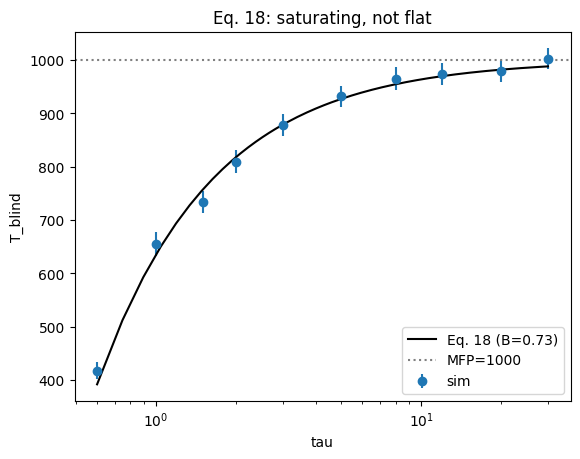

In [ ]:
POLICY = 'optimised'          # 'pure' or 'optimised'
D1 = 20 * MFP

def blind_T(tau, W=2500, h=0.2, seed=7):
    if POLICY == 'pure':
        return run_flight(L, Nt, r, tau, [tau, D1], [0.0, 1.0], W=W, seed=seed, h=h)
    best = (np.inf, np.nan, np.nan)
    for wl in [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.6, 1.0]:
        m, s, f = run_flight(L, Nt, r, tau, [tau, D1], [1-wl, wl], W=W, seed=seed, h=h)
        if m < best[0]:
            best = (m, s, f)
            best_wl = wl
    print(f"  tau={tau:5.1f}  best wl={best_wl:.3f}")
    return best

print(f"\nCHECK 3 — Eq. 18   (POLICY = {POLICY})\n")
taus_b = np.array([0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 30.0])
taus_b = taus_b[taus_b < L / 3]
Tb, Sb = [], []
for t in taus_b:
    m, s, f = blind_T(float(t))
    Tb.append(m); Sb.append(s)
    print(f"  tau={t:5.1f}  T={m:8.2f} +- {s:5.2f}  cens={f:.3f}")
Tb, Sb = np.array(Tb), np.array(Sb)

for psi_try in (1.0, 2.0):
    f = lambda tau, Tinf, B: Tinf * (1 - B * (r / tau) ** psi_try)
    try:
        popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
        pred = f(taus_b, *popt)
        R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)
        print(f"\n  psi={psi_try:.0f}:  T_inf={popt[0]:7.1f}  B={popt[1]:.3f}  R2={R2:.4f}"
              f"   (MFP={MFP:.1f}, T_inf/MFP={popt[0]/MFP:.3f})")
    except Exception as e:
        print(f"  psi={psi_try}: fit failed: {e}")
print(f"\n  expect psi=1 to win. reference (rho=1e-3, pure): T_inf=1034, B=0.38, R2=0.949")
print(f"                        (rho=1e-3, optimised):      T_inf=1011, B=0.73, R2=0.967")

plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
tt = np.linspace(taus_b.min(), taus_b.max(), 200)
plt.plot(tt, T_blind_eq18(tt, r, B=B_PURE if POLICY == 'pure' else B_OPT),
         'k-', label=f'Eq. 18 (B={B_PURE if POLICY=="pure" else B_OPT})')
plt.axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')
plt.xscale('log'); plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
plt.title('Eq. 18: saturating, not flat'); plt.show()

### Checking with `rl_opts`

# 5. Guidelines: statistics, and doing this at scale

## 5.1 The error you are probably NOT measuring

`mfpt_visual` returns `std/sqrt(W)`. **That is the error over walkers within
ONE fixed target configuration.** But each call draws its targets from `seed`,
so `T` also depends on *which* arrangement of `Nt` targets you happened to get,
and that contribution **does not fall as `W` grows**. With `Nt = 90` the
configuration-to-configuration scatter can rival or exceed the walker noise.

Every number I quoted to you used a single configuration per point. The right
thing is to average over configurations:


In [ ]:
def mfpt_multiconfig(n_cfg=8, W_per=500, **kw):
    """Average over target configurations AND walkers. Reports both errors."""
    means = []
    for c in range(n_cfg):
        m, _, _ = mfpt_visual(seed=1000 + c, W=W_per, **kw)
        means.append(m)
    means = np.array(means)
    return means.mean(), means.std(ddof=1)/np.sqrt(n_cfg)   # <- honest SEM

At fixed total cost `n_cfg * W_per`, **prefer more configurations over more
walkers** once the walker SEM is below the config scatter. Diagnose the split
by holding `W` fixed and varying only the seed: the spread you see is the
config noise, and no amount of `W` will remove it.

## 5.2 Choosing W from the precision you need

Work backwards from the quantity, not from `T`:

| you want | error | so |
|----------|-------|-----|
| `T` to 1% | `sigma_T/T` | `W ~ (CV/0.01)^2`, `CV = std/mean ~ 1` for these near-exponential FPTs, so `W ~ 1e4` |
| `ell` to `dell` | `sigma_ell = VR*sigma_T/A` | `W ~ (VR*std/(A*dell))^2` — **grows as VR^2, falls as A^2** |
| `VR*` | boundary is where two noisy curves cross | error blows up where the curves are parallel; see 5.4 |

The `A^2` is the trap: a dense box (small `A`) needs *far* more walkers for the
same `ell` precision. At `rho=1e-3`, `A=637`; at `rho=8e-3`, `A=80`, i.e. the
same `sigma_ell` costs **63x** the walkers.

## 5.3 Variance reduction (cheap, do these first)

- **Common random numbers.** When comparing configurations (VR vs VR, theory vs
  sim), reuse the same `seed` so the *same* target field and starting positions
  are used. Differences then have far smaller variance than either term. This
  is why sweeps should share a seed and absolute values should not.
- **Reuse the target field across tau.** Build the tree once per configuration
  and loop tau inside; removes config noise from the *tau-dependence*, which is
  exactly what Eq. 18 is about.
- **Antithetic headings.** Pair each walker with one started at heading + pi.
- **Check censoring.** If `cens > 0.001`, raise `max_steps`/`max_path`; censored
  walkers are the slow ones, so censoring biases `T` DOWN, silently.

## 5.4 Getting VR* right

`VR*` is where `T_vis(VR)` crosses `T_blind`. Its error is
`sigma_VR* = sigma_T / |dT_vis/dVR|`, so it blows up wherever the curves are
shallow. Do **not** read `VR*` off a coarse grid: fit `T_vis(VR)` (it is smooth
and monotone) and solve for the crossing, propagating the errors. A 5-point VR
grid gives you a bracket, not a number — every `VR*` I quoted is a bracket.

## 5.5 Scaling up

**Profile first.** The bottleneck in `run_visual` is the pure-Python
`for k in range(len(p))` loop. Options, in increasing order of effort:

1. **Parallelise over parameter points** — embarrassingly parallel, near-linear
   speedup, zero risk:
   ```python
   from joblib import Parallel, delayed
   jobs = [(t, v, s) for t in taus for v in VRs for s in seeds]
   out = Parallel(n_jobs=-1)(delayed(mfpt_visual)(
             L=L, Nt=Nt, r=r, VR=v, tau=t, theta=THETA, W=W, seed=s, rule='dir')
             for t, v, s in jobs)
   ```
2. **Cache to disk keyed by ALL parameters** including seed and W. Grids die to
   kernel restarts; a dict + `json`/`joblib.Memory` pays for itself immediately.
3. **Vectorise the inner loop.** Most steps have 0 or 1 candidate neighbours.
   Fast-path them (`tree.query(k=1)`) and only take the slow path when
   `query_ball_point` returns >1. Typically the big win.
4. **numba** `@njit` the per-step kernel with a flat neighbour array, or
   rewrite the step in pure numpy over a padded `(W, k_max)` neighbour matrix.

**Budget realistically.** Cost per point ~ `W * E[steps]` and `E[steps] ~ T/d`.
Since `T ~ A*ln(tau/VR_eff) ~ 1/rho`, halving the density doubles the cost per
walker. A `(10 tau) x (6 VR) x (8 cfg)` grid at `W=500` is 480 calls — hours in
pure Python, minutes parallelised, seconds with a vectorised kernel.

## 5.6 What to check before believing a sweep

- `cens ~ 0` everywhere (else `T` is biased low)
- the theory window: `3d <= VR < tau <= 0.6b`, and `tau < L/3` for the sim
- `ell` independent of density (a strong structural check — if it drifts with
  `rho`, the Robin picture is failing or you have a bug)
- re-fit rather than reuse my constants if you move regime: they were all fitted
  at `rho=1e-3, r=0.5, VR~3, d=1`, and the cone law at a single `(r, VR)`.